# Helmholtz Equation 1D with PINNs with PML Boundary Conditions

This code is based on the following tutorial: 

Manuela Bastidas Olivares, Nicolás Guarín-Zapata. (2024). nicoguaro/pinns_mapi-3: Tutorial de PINNs MAPI-3 v1.0 (v1.0). Zenodo. https://doi.org/10.5281/zenodo.11974585

In [70]:
%matplotlib inline

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.autograd import grad

In [2]:
class Model(torch.nn.Module):
    def __init__(self, neurons, n_layers, activation=torch.sin):
        super(Model, self).__init__()
        self.activation = activation
        self.layers = torch.nn.ModuleList()
        self.layers.append(torch.nn.Linear(1, neurons))
        for _ in range(n_layers-2):
            self.layers.append(torch.nn.Linear(neurons, neurons))
        self.layers.append(torch.nn.Linear(neurons, 2))

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = self.activation(layer(x))
        x = self.layers[-1](x)
        return x

In [3]:
frequency = 5
velocity = 1.5
velocity_func = lambda x: torch.where(x < 0, velocity*torch.ones_like(x), 2*velocity*torch.ones_like(x))

In [4]:
def f_rhs(x, phase=torch.pi/6, sigma=0.01, amplitude=1.0, src_pos=-0.2):
    return amplitude*torch.exp(-((x - src_pos)**2) / (2 * sigma**2))*np.exp(1j*phase)

x_integral = torch.linspace(-1.0, 1.0, 1000, dtype=torch.float64)
u_max = torch.abs(torch.trapz(f_rhs(x_integral), x_integral) * (1/(2*2*np.pi*frequency/velocity)))

def e_x(x, freq, lpml=0.5):
    sigma_x = torch.where(
        torch.abs(x) >= 1 - lpml, 
        2*torch.pi*4*freq*((torch.abs(x)-(1 - lpml))/lpml)**2,
        0
    )
    
    return 1 - 1j * sigma_x / (2*torch.pi*freq)


def residual(u, x, f, e_x, freq, vel):
    u_real = u[:,0:1]
    u_imag = u[:,1:2]
    u_comp = torch.complex(u_real, u_imag)
    
    # Compute gradients for real and imaginary parts separately
    du_real = grad(u_real, x, grad_outputs=torch.ones_like(u_real), create_graph=True)[0]
    du_imag = grad(u_imag, x, grad_outputs=torch.ones_like(u_imag), create_graph=True)[0]
    
    # Second derivatives
    ddu_real = grad(du_real, x, grad_outputs=torch.ones_like(du_real), create_graph=True)[0]
    ddu_imag = grad(du_imag, x, grad_outputs=torch.ones_like(du_imag), create_graph=True)[0]
    ddu_comp = torch.complex(ddu_real, ddu_imag)

    wave_number = 2*torch.pi*freq/vel
    
    # Return the residual
    # return ddu_comp/wave_number**2 +  e_x(x, freq) * u_comp - f(x)/(u_max*wave_number**2)
    # return ddu_comp/(wave_number**2) +  u_comp - f(x)/(wave_number**2)

    return ddu_comp*u_max +  e_x(x, freq) * u_comp*u_max * wave_number**2 - f(x)


def loss_fn(u_model, x, f, e_x, freq, vel):
    u = u_model(x)
    res = residual(u, x, f, e_x, freq, vel)
    res_MSE = torch.mean(torch.abs(res)**2)
    bc = u_model(torch.tensor([-1.]))**2 + u_model(torch.tensor([1.]))**2
    return res_MSE + bc[0]
    # return res_MSE


def train(model, optimizer, scheduler, loss_fn, f, e_x, n_pts, iterations, freq, velocity_func):
    losses = []
    for iteration in range(iterations):  
        optimizer.zero_grad()
        x = torch.FloatTensor(n_pts,1).uniform_(-1., 1.).requires_grad_(True)
        velocity_array = velocity_func(x)
        loss = loss_fn(model, x, f, e_x, freq, velocity_array)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']
        
        if (iteration+1) % 100 == 0:
            print(f"Epoch {iteration+1}, LR: {current_lr:.8f}, Loss: {loss.item():.4f}")
    return losses

def train_lbfgs(model, optimizer_lbfgs, loss_fn, f, iterations, e_x, x, freq, velocity_func):

    def closure():
        optimizer_lbfgs.zero_grad()
        velocity_array = velocity_func(x)
        loss = loss_fn(model, x, f, e_x, freq, velocity_array)
        loss.backward()
        return loss
    
    losses = []
    for iteration in range(iterations): 
        loss = optimizer_lbfgs.step(closure)
        losses.append(loss.item())
        if (iteration+1) % 100 == 0:
            print(f"[L-BFGS] Epoch {iteration+1}, Loss: {loss.item():.4f}")
        
    return losses

In [5]:
display(u_max.item())

0.000598413420602149

In [10]:
nn = 40
nl = 5
model = Model(neurons=nn, n_layers=nl)
for layer in model.layers:
    torch.nn.init.xavier_uniform_(layer.weight, gain=torch.nn.init.calculate_gain('tanh'))  # Xavier/Glorot initialization
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-6)

# Número de parámetros
sum(p.numel() for p in model.parameters() if p.requires_grad)

5082

In [11]:
n_pts = 1000
iterations = 1000

In [12]:
start_lr = 1e-4
end_lr = 1e-5
gamma = (end_lr / start_lr) ** (1 / iterations)  # exponential decay factor

# Exponential scheduler
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

In [13]:
losses_adam = train(model, optimizer, scheduler, loss_fn, f_rhs, e_x, n_pts, iterations, frequency, velocity_func)

Epoch 100, LR: 0.00007943, Loss: 0.0104
Epoch 200, LR: 0.00006310, Loss: 0.0109
Epoch 300, LR: 0.00005012, Loss: 0.0122
Epoch 400, LR: 0.00003981, Loss: 0.0098
Epoch 500, LR: 0.00003162, Loss: 0.0098
Epoch 600, LR: 0.00002512, Loss: 0.0121
Epoch 700, LR: 0.00001995, Loss: 0.0089
Epoch 800, LR: 0.00001585, Loss: 0.0073
Epoch 900, LR: 0.00001259, Loss: 0.0077
Epoch 1000, LR: 0.00001000, Loss: 0.0086


In [14]:
optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.1, max_iter=20)
xlist_torch = torch.FloatTensor(n_pts,1).uniform_(-1., 1.).requires_grad_(True)

In [15]:
iterations = 500
losses_lbfgs = train_lbfgs(model, optimizer_lbfgs, loss_fn, f_rhs, iterations, e_x, xlist_torch, frequency, velocity_func)

[L-BFGS] Epoch 100, Loss: 0.0008
[L-BFGS] Epoch 200, Loss: 0.0001
[L-BFGS] Epoch 300, Loss: 0.0001
[L-BFGS] Epoch 400, Loss: 0.0001
[L-BFGS] Epoch 500, Loss: 0.0001


In [16]:
losses = losses_adam + losses_lbfgs

In [17]:
xlist = np.linspace(-1., 1., n_pts)
xlist_torch = torch.tensor(xlist, dtype=torch.float32, requires_grad=True).view(-1, 1)

In [18]:
u_ap = model(xlist_torch)
torch.save(u_ap, 'h_eq1d_pinnd_pml_solution.pt')
torch.save(xlist_torch, 'h_eq1d_pinnd_pml_xlist.pt')
torch.save(model.state_dict(), 'h_eq1d_pinnd_pml_model.pth')

Text(0, 0.5, 'u(x)')

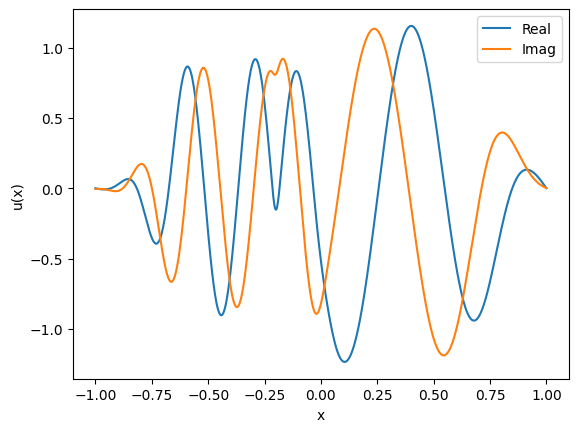

In [19]:
fig, ax = plt.subplots()
plt.plot(xlist, u_ap.detach().numpy())
plt.legend(['Real', 'Imag'])
plt.xlabel("x")
plt.ylabel("u(x)")

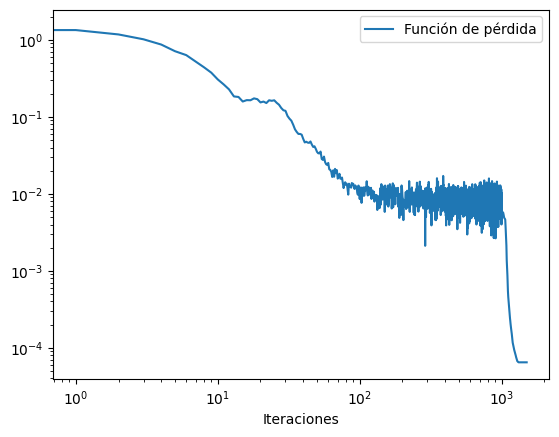

In [20]:
fig, ax = plt.subplots()
plt.loglog(losses)
plt.xlabel("Iteraciones")
plt.legend(['Función de pérdida'])

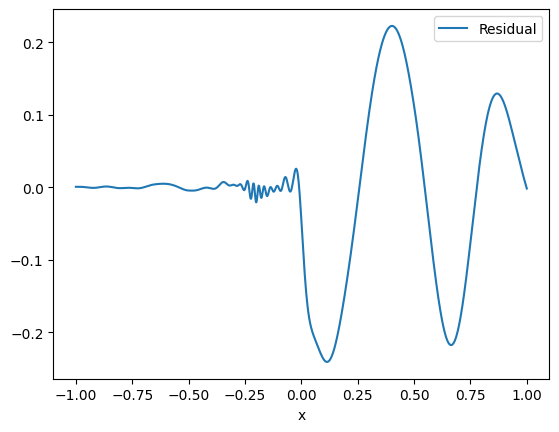

In [21]:
fig, ax = plt.subplots()
plt.plot(xlist, np.real(residual(u_ap, xlist_torch, f_rhs, e_x, frequency, velocity).detach().numpy()))
plt.xlabel("x")
plt.legend(["Residual"])

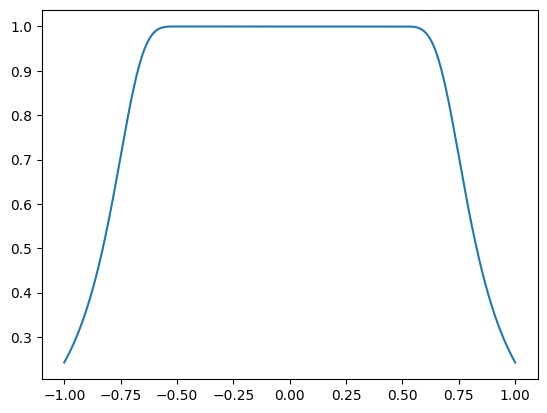

In [22]:
plt.figure()
plt.plot(xlist, np.abs(1/e_x(xlist_torch, freq=5).detach().numpy()))

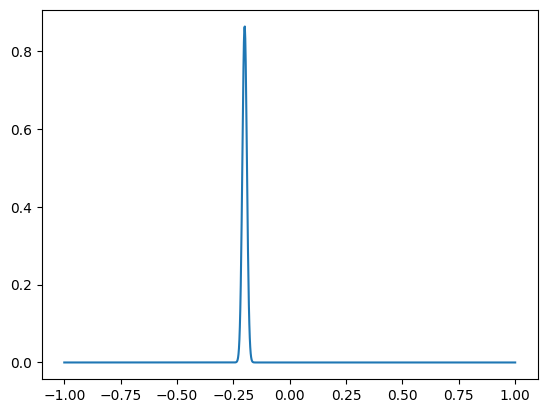

In [23]:
plt.figure()
plt.plot(xlist, np.real(f_rhs(xlist_torch).detach().numpy()))